# CA4: CA Groups 11
## Indra Bdr Adhikari, Zarar Zafar, and Syed Muhammad Murtaza Zaidi

## BACKGROUND

You have been hired by Nordic Bank Group, a financial services provider operating across Scandinavia. The bank is experiencing customer churn, where customers close their accounts and move to competing banks. Retaining existing customers is often significantly cheaper than acquiring new ones.

Your task is to develop a machine learning model capable of predicting whether a customer will leave the bank based on demographic and financial information. Accurate churn prediction models allow companies to identify customers who may leave and take proactive measures to retain them.

### Imports

- Load libraries for data handling and numerical operations  
- Load libraries for visualising feature distributions  
- Load preprocessing tools for imputing missing values and scaling features  
- Load utilities for pipelines and stratified train/validation splits  
- Load classifiers for model training  
- Load accuracy metric for evaluation

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns 
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

### Reading data

- Load the dataset into a dataframe  
- Inspect the number of rows and columns  
- Display the first rows to confirm correct loading  
- Check column names and data types

In [2]:
# Load the test data
test = pd.read_csv("test.csv")
print(test.shape)
test.head(1)

(2000, 13)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,5703,15749540,Hsiung,585,France,Male,36,7,0.0,2,1,0,94283.09


In [8]:
# Load the train data
df = pd.read_csv("train.csv")
print(df.info())
df.head(2)

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        8000 non-null   int64  
 1   CustomerId       8000 non-null   int64  
 2   Surname          8000 non-null   str    
 3   CreditScore      8000 non-null   int64  
 4   Geography        8000 non-null   str    
 5   Gender           8000 non-null   str    
 6   Age              8000 non-null   int64  
 7   Tenure           8000 non-null   int64  
 8   Balance          8000 non-null   float64
 9   NumOfProducts    8000 non-null   int64  
 10  HasCrCard        8000 non-null   int64  
 11  IsActiveMember   8000 non-null   int64  
 12  EstimatedSalary  8000 non-null   float64
 13  Exited           8000 non-null   int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1010.6 KB
None


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2152,15588614,Walton,753,France,Male,57,7,0.00,1,1,0,159475.08,1
1,8393,15641158,Belcher,739,Germany,Male,32,3,102128.27,1,1,0,63981.37,1


### Data exploration and visualisation

- Examine data types of all features  
- Visualise numeric feature distributions using histograms  
- Analyse correlations between numeric features using a heatmap  
- Identify value ranges and potential outliers

In [4]:
print(df.isnull().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [5]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,8000.000000,8.000000e+03,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.00000
mean,4990.432875,1.569088e+07,650.752500,38.946625,5.016625,76381.207499,1.529500,0.708750,0.514875,99730.811581,0.20375
std,2896.482331,7.193619e+04,96.596432,10.526876,2.896791,62302.053597,0.581741,0.454367,0.499810,57335.116540,0.40281
min,1.000000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.00000
25%,2461.750000,1.562869e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.000000,0.000000,50691.817500,0.00000
50%,4987.500000,1.568995e+07,652.000000,37.000000,5.000000,97055.145000,1.000000,1.000000,1.000000,99446.940000,0.00000
75%,7509.500000,1.575327e+07,717.000000,44.000000,8.000000,127633.195000,2.000000,1.000000,1.000000,148527.730000,0.00000
max,10000.000000,1.581569e+07,850.000000,92.000000,10.000000,238387.560000,4.000000,1.000000,1.000000,199992.480000,1.00000


In [39]:
df.corr()

ValueError: could not convert string to float: 'Walton'

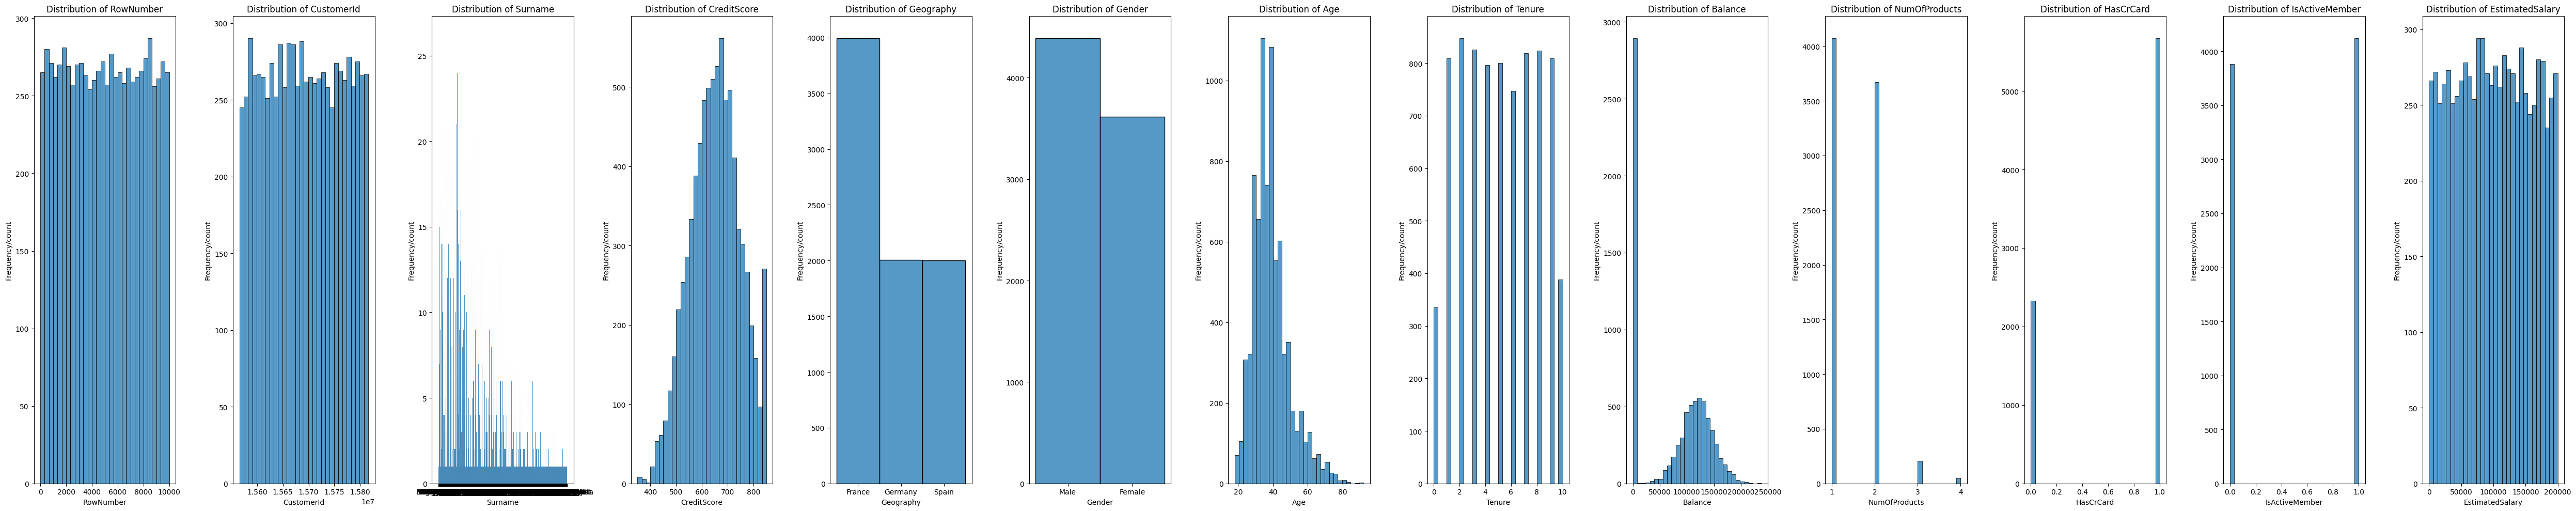

In [11]:
features = df.columns.drop("Exited")

fig, axes = plt.subplots(1, len(features), figsize=(50, 10))

for i, feature in enumerate(features):
    sns.histplot(df[feature], bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency/count')

plt.tight_layout()
plt.show()

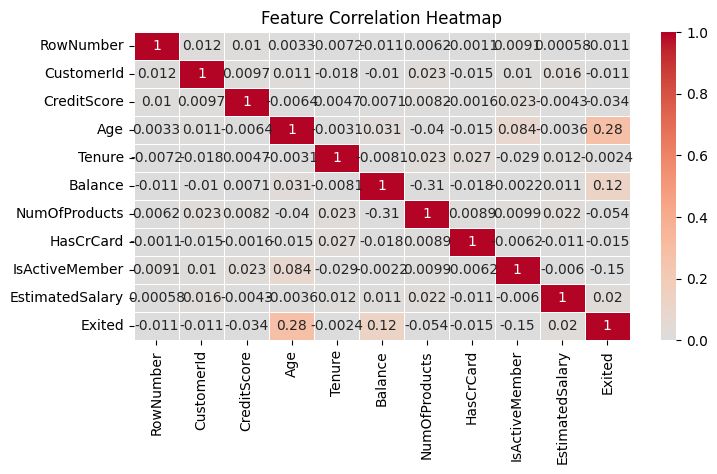

In [10]:
# Calculate the correlation matrix for numeric columns only and except "ID" columns
corr_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(8, 4))

# Draw the heatmap
sns.heatmap(corr_matrix, 
            annot=True,      
            cmap='coolwarm',
            vmin=0, vmax=1, 
            center=0,        # Ensure 0 is the neutral color 
            linewidths=0.5)  # Add small gaps

plt.title("Feature Correlation Heatmap")
plt.show()

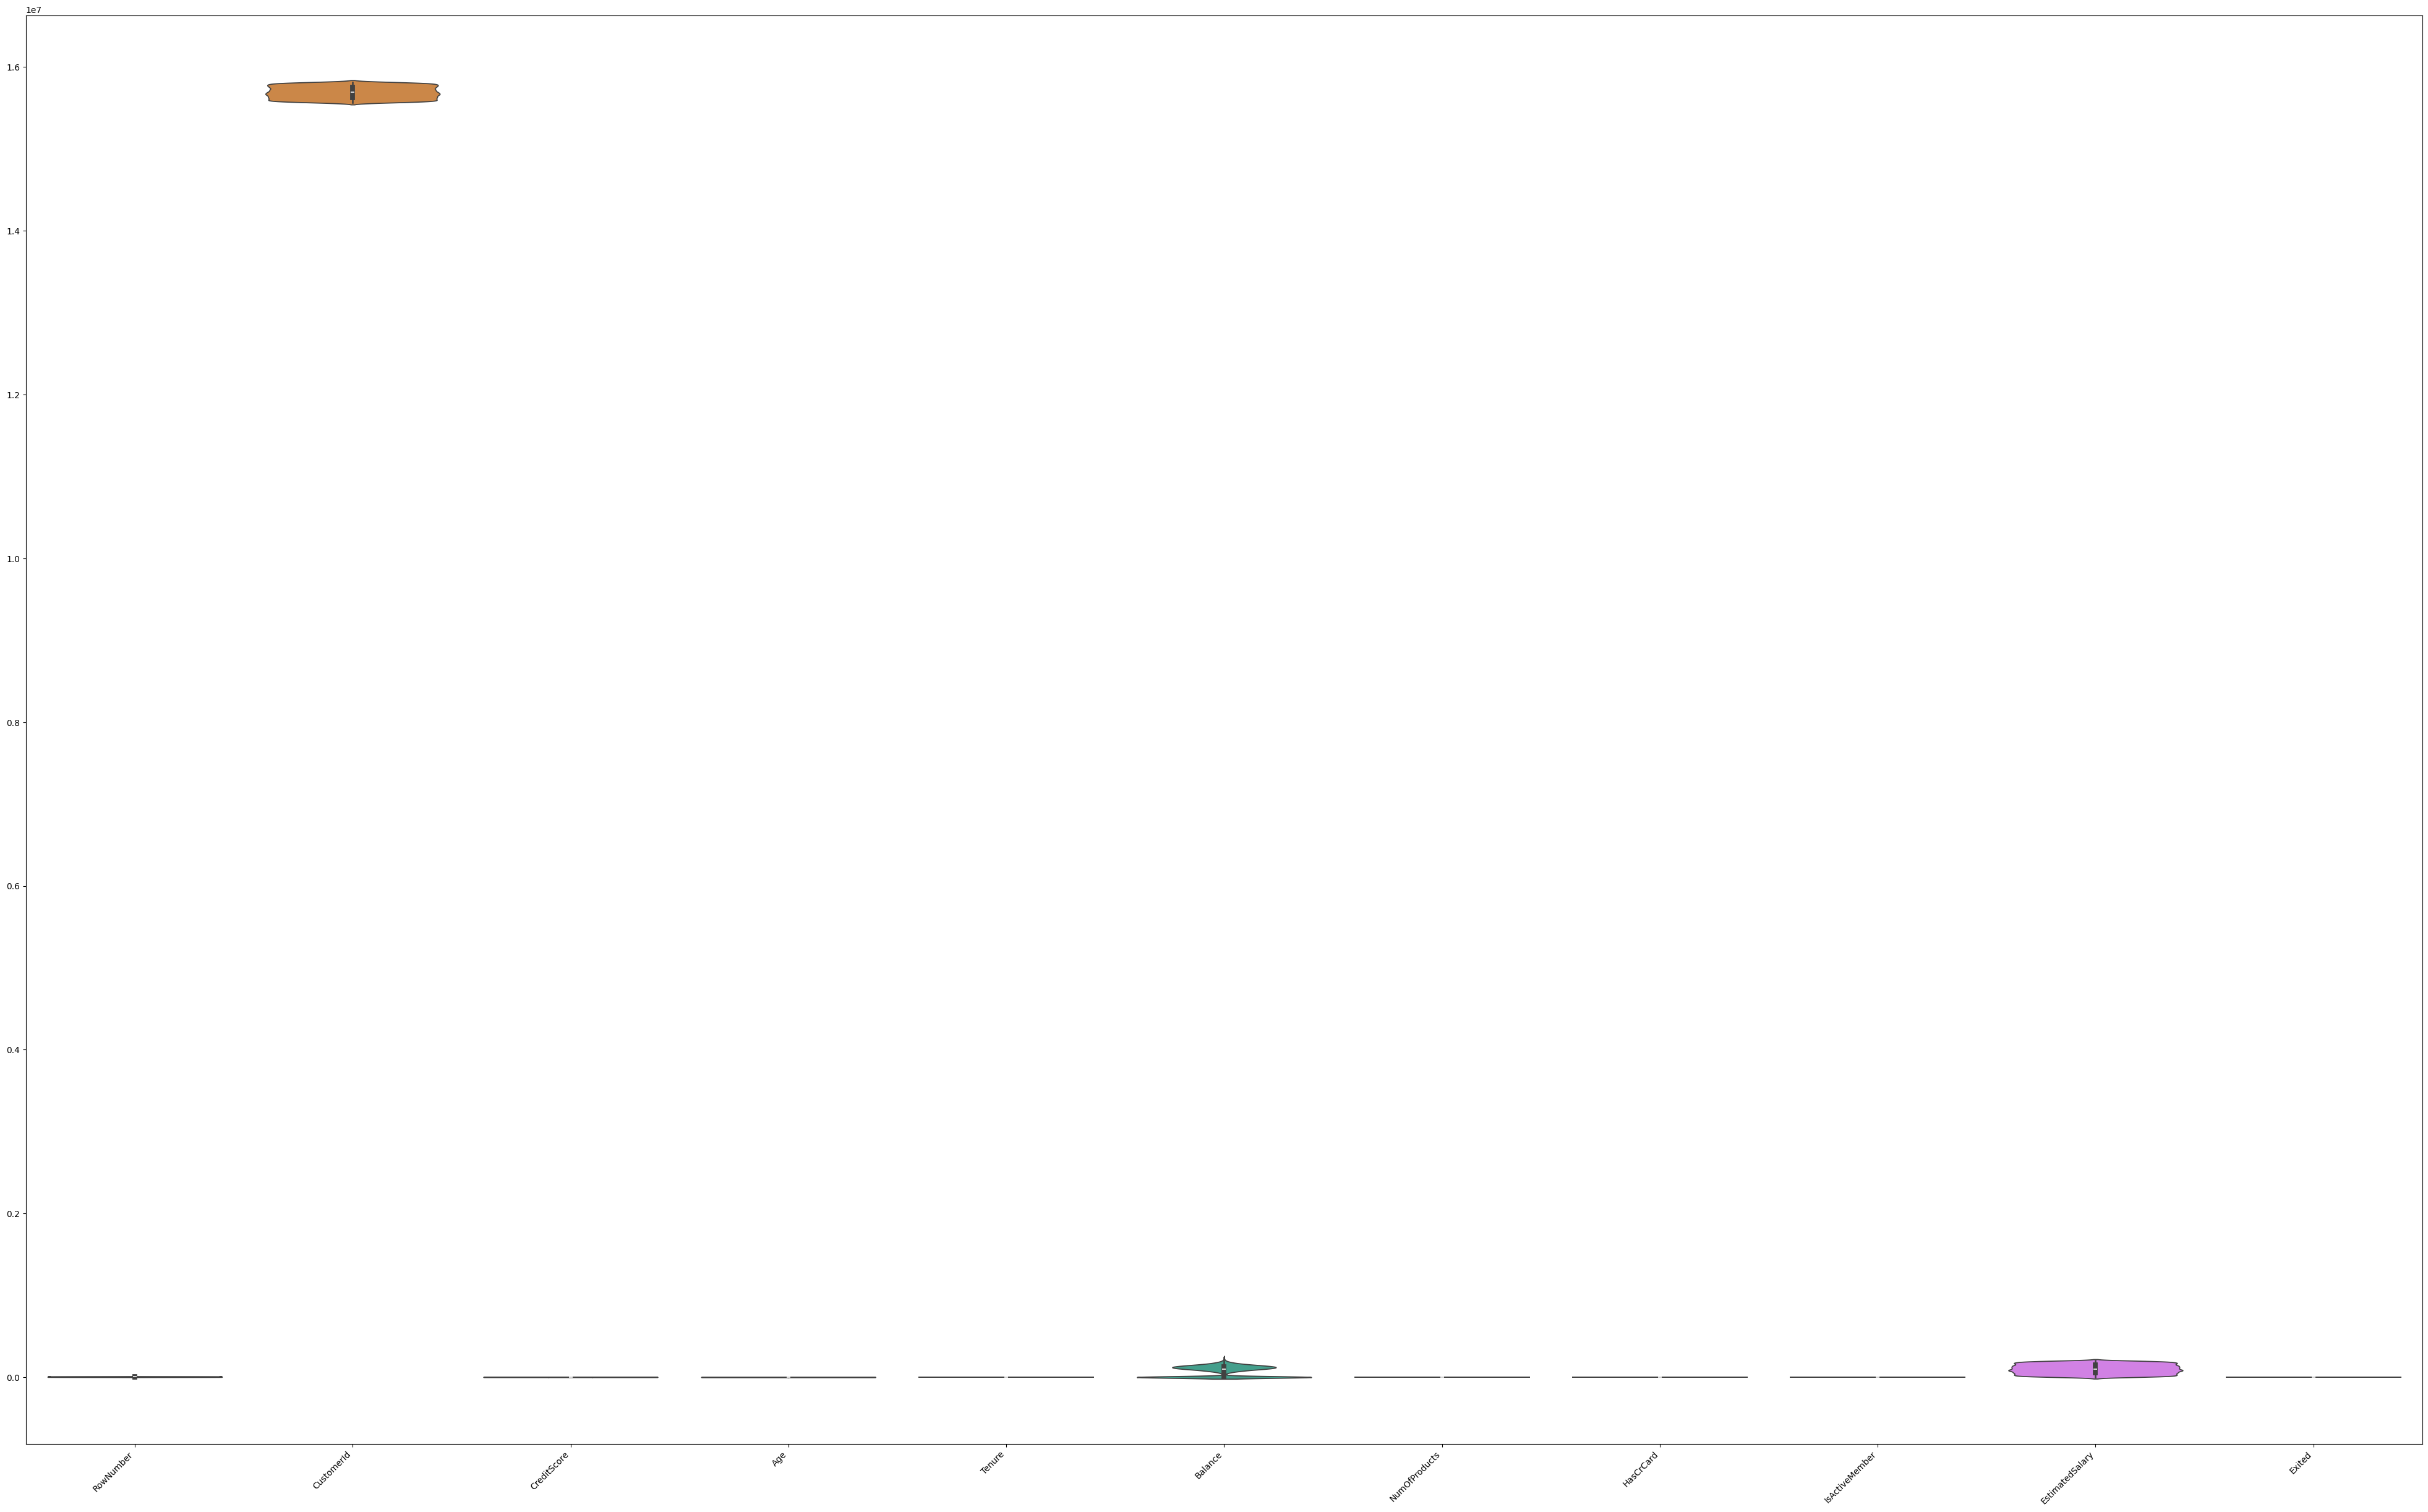

In [15]:
# Identify value ranges and potential outliers
cols=df.columns

fig, ax = plt.subplots(1, 1, figsize=(50, 30))  

data = pd.DataFrame(df, columns=cols)  

sns.violinplot(data=data, ax=ax)
plt.xticks(rotation=45, ha='right')
plt.show()

### Data cleaning
 
- Remove duplicates
- Standardise column names
- Convert feature columns to numeric
- Verify class balance

In [19]:
# Duplicates with columns ID
df.duplicated().sum()

0

In [21]:
# Duplicates without columns ID
df.duplicated().sum()

0

In [23]:
# Creating new df without columns ID
new_df = df
new_df.shape

(8000, 14)

In [24]:
new_df.columns.tolist()

['RowNumber',
 'CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [31]:
# Standardise column names
new_df.columns = new_df.columns.str.lower()
features = features.str.lower()
new_df.columns.tolist()

['rownumber',
 'customerid',
 'surname',
 'creditscore',
 'geography',
 'gender',
 'age',
 'tenure',
 'balance',
 'numofproducts',
 'hascrcard',
 'isactivemember',
 'estimatedsalary',
 'exited']

In [32]:
features

Index(['rownumber', 'customerid', 'surname', 'creditscore', 'geography',
       'gender', 'age', 'tenure', 'balance', 'numofproducts', 'hascrcard',
       'isactivemember', 'estimatedsalary'],
      dtype='str')

In [33]:
# checking features data type
new_df[features].dtypes

rownumber            int64
customerid           int64
surname                str
creditscore          int64
geography              str
gender                 str
age                  int64
tenure               int64
balance            float64
numofproducts        int64
hascrcard            int64
isactivemember       int64
estimatedsalary    float64
dtype: object

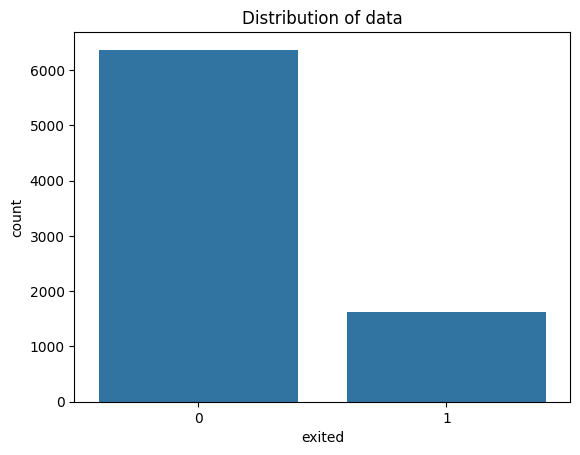

In [34]:
#verify class balance
sns.countplot(x='exited', data=new_df)
plt.title('Distribution of data')
plt.show()

### Data preprocessing

- Separate features and target variable  
- Select numeric features for modelling  
- Identify columns to exclude
- Check for missing values in the feature matrix  
- Prepare a feature list for the preprocessing pipeline

In [36]:
# Separate features and target variable  
features = features
target = "exited"

In [38]:
# Checking corrilation of new df
new_df.corr() 

ValueError: could not convert string to float: 'Walton'

In [ ]:
# Checking for missing values in the feature matrix and target
new_features = features[0:5]

X = new_df[new_features]
y = new_df[target]

print(X.isnull().sum())
y.isnull().sum()

In [ ]:
# Source; from lecture 12, to use the random forrest for features selection.

# Split the data into a training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a random forest classifier
clf = RandomForestClassifier(n_estimators=500, random_state=42)
clf.fit(X_train, y_train)

# Print the feature ranking as a list
print("Feature ranking (descending importance):")
ranking = { features[i]: clf.feature_importances_[i] for i in range(X.shape[1]) }
feature_name_max_length = max(ranking.keys(), key=len)
for i, feature in enumerate(sorted(ranking, key=ranking.get, reverse=True)):
    print(f"{i+1:2d}) {ranking[feature]:.4f} {feature}")

# Plot the feature importances of the forest
# Feature names on the y-axis, importances on the x-axis
# The most important features are at the top
# This means we first have to sort the features
feature_importance = clf.feature_importances_
indices = np.argsort(feature_importance)

plt.figure()
plt.title("Feature importance")
plt.yticks(range(X.shape[1]), np.array(features)[indices])

# Add error bars as well by computing the standard deviation of the feature importances
std = np.std([tree.feature_importances_ for tree in clf.estimators_], axis=0)
plt.barh(range(X.shape[1]), feature_importance[indices], xerr=std[indices], align="center")

plt.show()